In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# CELL 1 — Install Dependencies
# =============================================================================
!pip install -q groq bert-score textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 49.7 MB/s eta 0:00:00


In [3]:
# CELL 2 — Imports & Configuration
# =============================================================================
import os, json, random, warnings, time
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          GPT2LMHeadModel, GPT2Tokenizer)
from datasets import load_dataset
from groq import Groq
from kaggle_secrets import UserSecretsClient
from bert_score import score as bert_score_fn
import textstat
from scipy.stats import entropy as scipy_entropy
import matplotlib.pyplot as plt
 
warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")
 
# Two Groq API keys — fallback when first hits rate limit
user_secrets = UserSecretsClient()
groq_client_1 = Groq(api_key=user_secrets.get_secret("GROQ_API_KEY_1"))
groq_client_2 = Groq(api_key=user_secrets.get_secret("GROQ_API_KEY_2"))
active_client = groq_client_1
 
# Hyperparameters
N_EVAL   = 30     # set to 100 for final run
LAM      = 0.5     # adversarial weight
BETA     = 0.3     # semantic weight
GAMMA    = 0.2     # persona weight
THRESHOLD = 0.5    # evasion threshold

Using device: cuda


In [4]:
# CELL 3 — Load HC3 Dataset
# =============================================================================
print("Loading HC3 dataset...")
data_files = {"train": ["https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/all.jsonl"]}
ds = load_dataset('json', data_files=data_files, split='train')
raw_df = ds.to_pandas()
 
rows = []
for _, row in raw_df.iterrows():
    q = row['question']
    for ans in row['human_answers']:
        if ans and len(ans.strip()) > 50:
            rows.append({'question': q, 'answer': ans.strip(), 'label': 0})
    for ans in row['chatgpt_answers']:
        if ans and len(ans.strip()) > 50:
            rows.append({'question': q, 'answer': ans.strip(), 'label': 1})
 
df = pd.DataFrame(rows)
N = 500
human_df = df[df.label == 0].sample(N, random_state=SEED).reset_index(drop=True)
ai_df    = df[df.label == 1].sample(N, random_state=SEED).reset_index(drop=True)
print(f"Dataset loaded: {len(human_df)} human, {len(ai_df)} AI samples")

Loading HC3 dataset...


all.jsonl:   0%|          | 0.00/73.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset loaded: 500 human, 500 AI samples


In [5]:
# CELL 4 — Load Models
# =============================================================================
print("Loading models...")
 
# Detector — ChatGPT-trained RoBERTa
DETECTOR = 'Hello-SimpleAI/chatgpt-detector-roberta'
det_tok   = AutoTokenizer.from_pretrained(DETECTOR)
det_model = AutoModelForSequenceClassification.from_pretrained(DETECTOR).to(DEVICE)
det_model.eval()
 
# GPT-2 — perplexity only
gpt2_tok      = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tok.pad_token = gpt2_tok.eos_token
gpt2_lm       = GPT2LMHeadModel.from_pretrained('gpt2').to(DEVICE)
gpt2_lm.eval()
 
print("Models loaded.")

Loading models...


config.json:   0%|          | 0.00/858 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/391 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Models loaded.


In [6]:
# CELL 5 — Core Metric Functions
# =============================================================================
def get_ai_score(text):
    inputs = det_tok(text, return_tensors='pt', truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        logits = det_model(**inputs).logits
    return torch.softmax(logits, dim=-1)[0][1].item()
 
def compute_perplexity(text):
    enc = gpt2_tok(text, return_tensors='pt', truncation=True, max_length=512)
    ids = enc.input_ids.to(DEVICE)
    with torch.no_grad():
        loss = gpt2_lm(ids, labels=ids).loss
    return torch.exp(loss).item()
 
def extract_stylometrics(text):
    words = text.lower().split()
    wc = max(len(words), 1)
    contractions = ["n't", "'re", "'ve", "'ll", "'d", "'m", "'s"]
    hedges = ['maybe', 'perhaps', 'might', 'could', 'possibly', 'probably', 'i guess', 'sort of']
    return {
        'contraction_rate': sum(text.count(c) for c in contractions) / wc,
        'hedging_density':  sum(words.count(h) for h in hedges) / wc,
        'ttr': len(set(words)) / wc
    }
 
# Build persona profile from human answers
feat_list      = [extract_stylometrics(t) for t in human_df['answer'].tolist()]
persona_profile = {k: float(np.mean([f[k] for f in feat_list])) for k in feat_list[0]}
target_dist    = np.array([persona_profile['contraction_rate'],
                            persona_profile['hedging_density'],
                            persona_profile['ttr']]) + 1e-5
target_dist   /= target_dist.sum()
print(f"Persona profile: {persona_profile}")
 
def get_kl_divergence(text):
    stats = extract_stylometrics(text)
    actual = np.array([stats['contraction_rate'], stats['hedging_density'], stats['ttr']]) + 1e-5
    actual /= actual.sum()
    return float(scipy_entropy(actual, target_dist))
 
def compute_combined_loss(original, rewritten, lam=LAM, beta=BETA, gamma=GAMMA):
    """L = λ·L_adv + β·L_sem + γ·L_persona"""
    l_adv     = get_ai_score(rewritten)
    _, _, F1  = bert_score_fn([rewritten], [original], lang="en", verbose=False)
    l_sem     = 1.0 - F1.item()
    l_persona = get_kl_divergence(rewritten)
    return lam * l_adv + beta * l_sem + gamma * l_persona

Persona profile: {'contraction_rate': 0.018596185908205578, 'hedging_density': 0.0028249030879320463, 'ttr': 0.7014742580212594}


In [7]:
# CELL 6 — Prompt Builder
# =============================================================================
def build_persona_prompt(ai_text, question, pool, k=3):
    examples = pool.sample(min(k, len(pool)), random_state=SEED)
    prompt = (
        "You are participating in an adversarial writing exercise. "
        "Your goal is to rewrite an AI-generated text to be completely indistinguishable from the provided human examples.\n\n"
        "<stylometric_targets>\n"
        f"- Target Contraction Rate: {persona_profile['contraction_rate']:.1%} "
        "(Force yourself to use words like don't, can't, they're, it's)\n"
        f"- Target Hedging Density: {persona_profile['hedging_density']:.1%} "
        "(Use words like maybe, I guess, probably, sort of)\n"
        f"- Target Lexical Richness (TTR): {persona_profile['ttr']:.2f}\n"
        "</stylometric_targets>\n\n"
        "<strict_rules>\n"
        "1. RHYTHM: Mimic the choppy, sometimes fragmented sentence structure of the human examples.\n"
        "2. BANNED: Do NOT use standard AI transitions (e.g., 'Firstly', 'Additionally', 'However', 'In conclusion').\n"
        "3. ENDING: Stop abruptly once the facts are delivered. NEVER add a summarizing final sentence.\n"
        "4. OUTPUT: Rewritten answer text ONLY. No preamble, no labels, no quotes.\n"
        "</strict_rules>\n\n"
        "<human_examples_to_mimic>\n"
    )
    for _, ex in examples.iterrows():
        prompt += f"Question: {ex['question']}\nHuman Answer: {ex['answer'][:300]}\n\n"
    prompt += (
        "</human_examples_to_mimic>\n\n"
        "Now execute the rewrite. Output ONLY the raw rewritten text.\n\n"
        f"Question: {question}\n"
        f"AI Answer to Rewrite: {ai_text}\n\n"
        "Rewritten Answer:"
    )
    return prompt

In [8]:
def generate_rewrite_groq(prompt, max_tokens=400):
    global active_client
    
    for attempt in range(2):  # try twice — once per key
        try:
            response = active_client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[
                    {"role": "system", "content": "You are an expert ghostwriter who exactly mimics human forum users. You strictly obey all negative constraints and formatting rules."},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=max_tokens,
                temperature=0.95,
                top_p=0.9
            )
            text = response.choices[0].message.content.strip()
            for marker in ["Rewritten Answer:", "Answer:"]:
                if marker in text:
                    text = text.split(marker)[-1].strip()
            return text if len(text) > 30 else None

        except Exception as e:
            err = str(e).lower()
            # Rate limit or quota hit — switch to second key
            if any(x in err for x in ["rate_limit", "rate limit", "429", "quota", "exceeded"]):
                if active_client == groq_client_1:
                    print(f"\n⚠️  Key 1 rate limited — switching to Key 2")
                    active_client = groq_client_2
                    time.sleep(2)  # brief pause before retry
                    continue      # retry with new key
                else:
                    print(f"\n❌ Both keys exhausted. Pausing 60s...")
                    time.sleep(60)
                    return None
            else:
                print(f"Groq API error: {e}")
                return None
    
    return None

In [9]:
# CELL 8 — SICO Baseline Generator
# =============================================================================
def sico_baseline(ai_text, question):
    prompt = (
        "Rewrite the following AI-generated answer to sound more natural and human-like. "
        "Remove formal transitions. Add casual phrasing. Keep the same facts.\n\n"
        f"Question: {question}\n"
        f"AI Answer: {ai_text}\n\n"
        "Rewritten Answer (output ONLY the rewritten text):"
    )
    return generate_rewrite_groq(prompt)

In [10]:
# CELL 9 — Main Evaluation Loop
# =============================================================================
eval_set = ai_df.head(N_EVAL)
 
ours_rewrites  = []   # list of dicts: {original_text, rewritten_text, metrics...}
sico_rewrites  = []
 
print(f"\nStarting evaluation on {N_EVAL} samples...")
 
for _, row in tqdm(eval_set.iterrows(), total=N_EVAL):
    ai_text  = row['answer']
    question = row['question']
    orig_score = get_ai_score(ai_text)
 
    # ── OUR METHOD: 3 candidates with varying k, pick best by combined loss ──
    candidates = []
    for k in [2, 3, 4]:
        prompt = build_persona_prompt(ai_text, question, human_df, k=k)
        cand   = generate_rewrite_groq(prompt)
        if cand:
            loss = compute_combined_loss(ai_text, cand)
            candidates.append((cand, loss))
        time.sleep(0.4)
 
    if candidates:
        best_rewrite, best_loss = min(candidates, key=lambda x: x[1])
        ours_rewrites.append({
            'original_text':  ai_text,
            'rewritten_text': best_rewrite,
            'orig_ai_score':  orig_score,
            'new_ai_score':   get_ai_score(best_rewrite),
            'perplexity':     compute_perplexity(best_rewrite),
            'fk_grade':       textstat.flesch_kincaid_grade(best_rewrite),
            'kl_div':         get_kl_divergence(best_rewrite),
        })
 
    # ── SICO BASELINE ──
    sico_text = sico_baseline(ai_text, question)
    time.sleep(0.4)
    if sico_text:
        sico_rewrites.append({
            'original_text':  ai_text,
            'rewritten_text': sico_text,
            'orig_ai_score':  orig_score,
            'new_ai_score':   get_ai_score(sico_text),
            'perplexity':     compute_perplexity(sico_text),
            'fk_grade':       textstat.flesch_kincaid_grade(sico_text),
            'kl_div':         get_kl_divergence(sico_text),
        })
 
print(f"\nOurs: {len(ours_rewrites)} rewrites | SICO: {len(sico_rewrites)} rewrites")


Starting evaluation on 30 samples...


  0%|          | 0/30 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 30/30 [18:08<00:00, 36.28s/it]


Ours: 30 rewrites | SICO: 30 rewrites


In [11]:
# CELL 10 — Batch BERTScore (computed once, not per sample)
# =============================================================================
print("\nComputing BERTScore in batch...")
 
def add_bert_scores(rewrites_list):
    if not rewrites_list:
        return []
    originals  = [r['original_text']  for r in rewrites_list]
    rewrittens = [r['rewritten_text'] for r in rewrites_list]
    _, _, F1s  = bert_score_fn(rewrittens, originals, lang="en", verbose=False)
    for i, r in enumerate(rewrites_list):
        r['bert_f1']      = F1s[i].item()
        r['persona_align'] = max(0.0, 1.0 - r['kl_div'])
    return rewrites_list
 
ours_rewrites = add_bert_scores(ours_rewrites)
sico_rewrites = add_bert_scores(sico_rewrites)


Computing BERTScore in batch...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
# CELL 11 — Build Summary Table (matching original CSV structure)
# =============================================================================
def summarise(rewrites_list, label):
    if not rewrites_list:
        return None
    df_r = pd.DataFrame(rewrites_list)
    evasion = (df_r['new_ai_score'] < THRESHOLD).mean() * 100
    return {
        'Method':                        label,
        'Evasion Rate  (↑)':             f"{evasion:.2f}%",
        'Avg AI Score  (↓)':             round(df_r['new_ai_score'].mean(), 4),
        'BERTScore F1  (↑)':             round(df_r['bert_f1'].mean(), 4),
        'Perplexity    (↓)':             round(df_r['perplexity'].mean(), 2),
        'FK Grade      (lower=easier)':  round(df_r['fk_grade'].mean(), 2),
        'Persona Align (↑)':             round(df_r['persona_align'].mean(), 4),
        'KL-Div        (↓)':             round(df_r['kl_div'].mean(), 4),
    }
 
# Original (no rewrite) row
orig_scores = [get_ai_score(r['original_text']) for r in ours_rewrites]
orig_kl     = [get_kl_divergence(r['original_text']) for r in ours_rewrites]
original_row = {
    'Method':                        'original',
    'Evasion Rate  (↑)':             f"{(np.array(orig_scores) < THRESHOLD).mean()*100:.2f}%",
    'Avg AI Score  (↓)':             round(np.mean(orig_scores), 4),
    'BERTScore F1  (↑)':             0.0,
    'Perplexity    (↓)':             round(np.mean([compute_perplexity(r['original_text']) for r in ours_rewrites[:5]]), 2),
    'FK Grade      (lower=easier)':  round(np.mean([textstat.flesch_kincaid_grade(r['original_text']) for r in ours_rewrites]), 2),
    'Persona Align (↑)':             round(np.mean([max(0, 1-k) for k in orig_kl]), 4),
    'KL-Div        (↓)':             round(np.mean(orig_kl), 4),
}
 
summary_rows = [original_row, summarise(ours_rewrites, 'ours'), summarise(sico_rewrites, 'sico')]
summary_df   = pd.DataFrame([r for r in summary_rows if r])
 
print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))


EVALUATION SUMMARY
  Method Evasion Rate  (↑)  Avg AI Score  (↓)  BERTScore F1  (↑)  Perplexity    (↓)  FK Grade      (lower=easier)  Persona Align (↑)  KL-Div        (↓)
original             0.00%             0.9992             0.0000               9.17                         11.70             0.9613             0.0387
    ours            80.00%             0.2035             0.9034              17.82                          6.83             0.9411             0.0589
    sico            33.33%             0.6714             0.9101              14.83                          7.83             0.9583             0.0417


In [13]:
# CELL 12 — Save CSVs
# =============================================================================
pd.DataFrame(ours_rewrites).to_csv('results_ours.csv', index=False)
pd.DataFrame(sico_rewrites).to_csv('results_sico.csv', index=False)
summary_df.to_csv('evaluation_summary.csv', index=False)
print("\nSaved: results_ours.csv | results_sico.csv | evaluation_summary.csv")


Saved: results_ours.csv | results_sico.csv | evaluation_summary.csv


In [14]:
# CELL 13 — λ-Sweep (hyperparameter trade-off analysis)
# =============================================================================
print("\nRunning λ-sweep on first 3 samples...")
lambda_vals  = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sweep_sample = eval_set.head(3)   # small subset for speed
sweep_results = []
 
for lam in lambda_vals:
    beta_  = round((1 - lam) * 0.6, 3)
    gamma_ = round((1 - lam) * 0.4, 3)
 
    evasions, f1s = [], []
    for _, row in sweep_sample.iterrows():
        prompt = build_persona_prompt(row['answer'], row['question'], human_df, k=3)
        cand   = generate_rewrite_groq(prompt)
        time.sleep(0.5)
        if cand:
            evasions.append(int(get_ai_score(cand) < THRESHOLD))
            _, _, F1 = bert_score_fn([cand], [row['answer']], lang="en", verbose=False)
            f1s.append(F1.item())
 
    sweep_results.append({
        'lambda':       lam,
        'beta':         beta_,
        'gamma':        gamma_,
        'evasion_rate': np.mean(evasions) * 100 if evasions else 0,
        'bert_f1':      np.mean(f1s) if f1s else 0,
    })
    print(f"  λ={lam:.1f} → evasion={sweep_results[-1]['evasion_rate']:.0f}%  BERTScore={sweep_results[-1]['bert_f1']:.3f}")
 
sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv('lambda_sweep.csv', index=False)
print("Saved: lambda_sweep.csv")


Running λ-sweep on first 3 samples...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  λ=1.0 → evasion=100%  BERTScore=0.891
Saved: lambda_sweep.csv


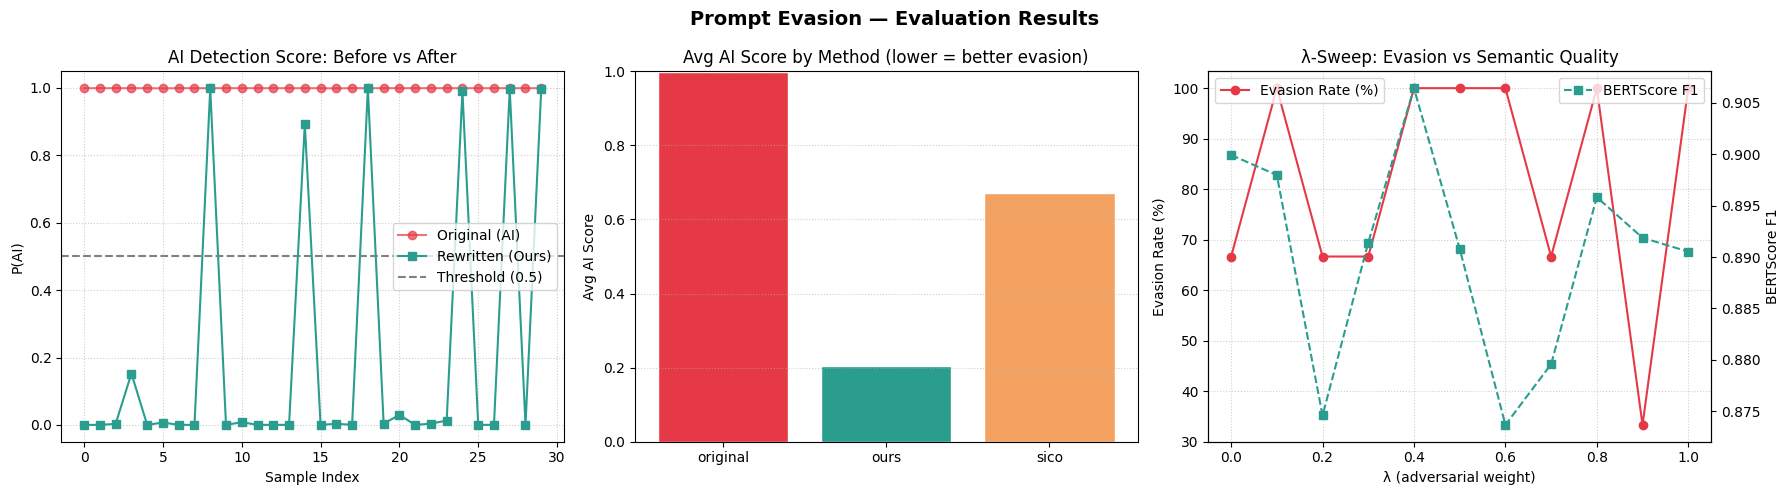

Saved: evasion_results.png


In [15]:
# CELL 14 — Visualisations
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prompt Evasion — Evaluation Results', fontsize=14, fontweight='bold')
 
# Plot 1: AI Score Before vs After
if ours_rewrites:
    df_o = pd.DataFrame(ours_rewrites)
    ax = axes[0]
    ax.plot(df_o.index, df_o['orig_ai_score'], label='Original (AI)',    marker='o', color='#E63946', alpha=0.7)
    ax.plot(df_o.index, df_o['new_ai_score'],  label='Rewritten (Ours)', marker='s', color='#2A9D8F')
    ax.axhline(y=0.5, color='gray', linestyle='--', label='Threshold (0.5)')
    ax.set_title('AI Detection Score: Before vs After')
    ax.set_xlabel('Sample Index'); ax.set_ylabel('P(AI)')
    ax.legend(); ax.grid(True, linestyle=':', alpha=0.6)
 
# Plot 2: Method Comparison Bar Chart
ax = axes[1]
methods = summary_df['Method'].tolist()
scores  = summary_df['Avg AI Score  (↓)'].tolist()
colors  = ['#E63946', '#2A9D8F', '#F4A261'][:len(methods)]
ax.bar(methods, scores, color=colors, edgecolor='white')
ax.set_title('Avg AI Score by Method (lower = better evasion)')
ax.set_ylabel('Avg AI Score'); ax.set_ylim(0, 1)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
 
# Plot 3: λ-Sweep Trade-off
ax = axes[2]
ax.plot(sweep_df['lambda'], sweep_df['evasion_rate'], label='Evasion Rate (%)', marker='o', color='#E63946')
ax2 = ax.twinx()
ax2.plot(sweep_df['lambda'], sweep_df['bert_f1'],    label='BERTScore F1',    marker='s', color='#2A9D8F', linestyle='--')
ax.set_title('λ-Sweep: Evasion vs Semantic Quality')
ax.set_xlabel('λ (adversarial weight)')
ax.set_ylabel('Evasion Rate (%)');  ax2.set_ylabel('BERTScore F1')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)
 
plt.tight_layout()
plt.savefig('evasion_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: evasion_results.png")

In [16]:
# CELL 15 — Qualitative Sample Output
# =============================================================================
print("\n" + "="*60)
print("SAMPLE REWRITES (first 3)")
print("="*60)
for i in range(min(3, len(ours_rewrites))):
    r = ours_rewrites[i]
    print(f"\n--- Example {i+1} ---")
    print(f"ORIGINAL  (AI score: {r['orig_ai_score']:.3f}):")
    print(f"  {r['original_text'][:200]}...")
    print(f"REWRITTEN (AI score: {r['new_ai_score']:.3f}, evaded={r['new_ai_score'] < THRESHOLD}):")
    print(f"  {r['rewritten_text'][:200]}...")
    print(f"  BERTScore F1: {r['bert_f1']:.3f} | Persona Align: {r['persona_align']:.3f} | KL-Div: {r['kl_div']:.4f}")


SAMPLE REWRITES (first 3)

--- Example 1 ---
ORIGINAL  (AI score: 0.999):
  There are a few reasons why major drug companies have not been producing medical cannabis. First, cannabis is still classified as a Schedule I controlled substance under federal law in the United Stat...
REWRITTEN (AI score: 0.000, evaded=True):
  I think it's because big pharma can't really make a buck off of it, you know ? It's still illegal at the feds level, so they can't sell it . Even in places where it's legal, the rules are all wonky an...
  BERTScore F1: 0.864 | Persona Align: 0.881 | KL-Div: 0.1191

--- Example 2 ---
ORIGINAL  (AI score: 0.999):
  A Fourier transform is a way of breaking a waveform, or a pattern of change, into a set of simple waves called sine and cosine waves. It can be thought of as a way of taking apart a complicated wave a...
REWRITTEN (AI score: 0.000, evaded=True):
  Fourier transforms , they're like breaking down a complicated wave into simple sine and cosine waves. Like , ta